# Creative Fatigue — Explainability with Random Survival Forest + SHAP

This notebook extends the Cox PH analysis with a non-parametric model (Random Survival Forest) that can capture feature interactions, and uses SHAP to explain both:
- **Globally**: which creative attributes most strongly predict fatigue across all 1,080 creatives.
- **Individually**: for a single creative, *why* the model thinks it is at risk.

Final output: a **Creative Health Score** (0–100) for every still-running creative, with an actionable recommendation: `SCALE`, `MONITOR`, or `PAUSE`.

**Libraries required:** `scikit-survival`, `shap`, `lifelines`, `pandas`, `matplotlib`
```
pip install scikit-survival shap lifelines
```

In [1]:
# Uncomment if needed:
# !pip install scikit-survival shap lifelines --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from lifelines import KaplanMeierFitter
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
import shap

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
np.random.seed(42)

DATA = '../data'


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.star

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.star

AttributeError: _ARRAY_API not found

## 1. Load data and build the survival frame

Same framing as Notebook 1:
- **T** = `fatigue_day` for fatigued creatives; `total_days_active` for everyone else (right-censored).
- **E** = 1 if `creative_status == "fatigued"`, else 0.

We only use features observable **at launch** — no post-hoc leakage (no `ctr_decay_pct`, `perf_score`, etc.).

In [2]:
crs  = pd.read_csv(f'{DATA}/creative_summary.csv')
camp = pd.read_csv(f'{DATA}/campaigns.csv')[['campaign_id', 'target_os', 'kpi_goal', 'objective']]

surv = crs.merge(camp, on='campaign_id', how='left')

# Survival targets
surv['event']    = (surv['creative_status'] == 'fatigued').astype(int)
surv['duration'] = np.where(surv['event'] == 1, surv['fatigue_day'], surv['total_days_active']).astype(float)

# Sanity
assert (surv['duration'] > 0).all(), 'Zero-duration rows'
print(f'Total creatives : {len(surv)}')
print(f'Fatigued (event): {surv["event"].sum()} ({surv["event"].mean()*100:.1f}%)')
print(f'Censored        : {(1-surv["event"]).sum()}')
print()
print(surv['creative_status'].value_counts().to_string())

Total creatives : 1080
Fatigued (event): 199 (18.4%)
Censored        : 881

creative_status
stable            740
fatigued          199
underperformer     95
top_performer      46


## 2. Feature matrix — design decisions

We include three groups:

| Group | Features | Rationale |
|---|---|---|
| Structural | `vertical`, `format`, `target_os`, `objective` | Controls — creative features estimated within comparable groups |
| Visual/design | `text_density`, `clutter_score`, `novelty_score`, `motion_score`, `brand_visibility_score`, `readability_score` | Continuous scores pre-computed from creative assets |
| Creative elements | `faces_count`, `product_count`, `has_price`, `has_discount_badge`, `has_gameplay`, `has_ugc_style`, `duration_sec` | Binary/count flags with strong prior hypotheses |

**Excluded on purpose:** `ctr_decay_pct`, `perf_score`, `first_7d_ctr`, `last_7d_ctr` — all measured *after* fatigue, so they'd leak the label into the features.

In [3]:
CAT_COLS = ['vertical', 'format', 'target_os', 'objective', 'dominant_color', 'emotional_tone', 'hook_type', 'language']
NUM_COLS = [
    'text_density', 'readability_score', 'brand_visibility_score',
    'clutter_score', 'novelty_score', 'motion_score',
    'faces_count', 'product_count', 'duration_sec', 'copy_length_chars',
]
BIN_COLS = ['has_price', 'has_discount_badge', 'has_gameplay', 'has_ugc_style']

ALL_FEAT = CAT_COLS + NUM_COLS + BIN_COLS

X = surv[ALL_FEAT].copy()
X = pd.get_dummies(X, columns=CAT_COLS, drop_first=True, dtype=float)
X[NUM_COLS] = X[NUM_COLS].fillna(X[NUM_COLS].median())
X[BIN_COLS] = X[BIN_COLS].fillna(0)

# scikit-survival requires a structured array for y
y = Surv.from_arrays(event=surv['event'].astype(bool), time=surv['duration'])

print(f'Feature matrix shape: {X.shape}')
print(f'Feature names (first 15): {list(X.columns[:15])}')

Feature matrix shape: (1080, 75)
Feature names (first 15): ['text_density', 'readability_score', 'brand_visibility_score', 'clutter_score', 'novelty_score', 'motion_score', 'faces_count', 'product_count', 'duration_sec', 'copy_length_chars', 'has_price', 'has_discount_badge', 'has_gameplay', 'has_ugc_style', 'vertical_entertainment']


## 3. Train/test split — stratified on event

We hold out 20% for evaluation. Stratification ensures the test set has a proportional number of events (important when events are rare).

In [4]:
from sklearn.model_selection import train_test_split

idx_train, idx_test = train_test_split(
    np.arange(len(X)),
    test_size=0.2,
    stratify=surv['event'],
    random_state=42
)

X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

print(f'Train: {len(X_train)} creatives  |  Test: {len(X_test)} creatives')
print(f'Event rate — train: {y_train["event"].mean()*100:.1f}%  |  test: {y_test["event"].mean()*100:.1f}%')

Train: 864 creatives  |  Test: 216 creatives
Event rate — train: 18.4%  |  test: 18.5%


## 4. Fit the Random Survival Forest

RSF grows an ensemble of survival trees. Unlike Cox PH, it:
- Needs no proportionality assumption.
- Captures non-linear effects and interactions (e.g. `has_gameplay × novelty_score`).
- Outputs a full predicted survival function per creative, not just a scalar risk score.
- Is natively compatible with TreeSHAP for fast, exact Shapley values.

Hyperparameters are conservative for a hackathon environment (300 trees, min_leaf=15).

In [5]:
rsf = RandomSurvivalForest(
    n_estimators=300,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)
rsf.fit(X_train, y_train)

# Evaluation: concordance index
pred_risk_test = rsf.predict(X_test)  # higher = higher predicted hazard
c_idx = concordance_index_censored(y_test['event'], y_test['time'], pred_risk_test)[0]
print(f'Concordance index on test set: {c_idx:.3f}')
print('(0.5 = random, 1.0 = perfect; >0.65 is useful in this setting)')

Concordance index on test set: 0.755
(0.5 = random, 1.0 = perfect; >0.65 is useful in this setting)


## 5. SHAP values — global explainability

SHAP (SHapley Additive exPlanations) decomposes each prediction into the additive contribution of each feature. TreeSHAP computes exact values in polynomial time for tree-based models.

We use the **training set** as the background sample for SHAP computation (standard practice for RSF).

> **Interpretation:** A positive SHAP value means the feature *increased* the predicted hazard for this creative (more risk of fatigue). A negative SHAP value means it *reduced* the hazard (protective).

In [7]:
from sklearn.ensemble import RandomForestRegressor

# shap.TreeExplainer does not support RandomSurvivalForest directly.
# Workaround: train a surrogate RandomForestRegressor that mimics RSF predictions,
# then run TreeSHAP on the surrogate (fast, exact Shapley values).
pred_hazard_all = rsf.predict(X)
surrogate = RandomForestRegressor(n_estimators=300, max_features="sqrt", n_jobs=-1, random_state=42)
surrogate.fit(X, pred_hazard_all)

explainer = shap.TreeExplainer(surrogate)
shap_values = explainer.shap_values(X)

print(f'SHAP values shape: {np.array(shap_values).shape}')
print('Computed successfully.')

SHAP values shape: (1080, 75)
Computed successfully.


## 6. Global feature importance — mean |SHAP|

The most interpretable single-number summary: average absolute SHAP value per feature, across all creatives. This tells us which features the model leans on most to predict fatigue risk.

High `mean |SHAP|` = the feature moves the predicted hazard substantially, on average, across all creatives.

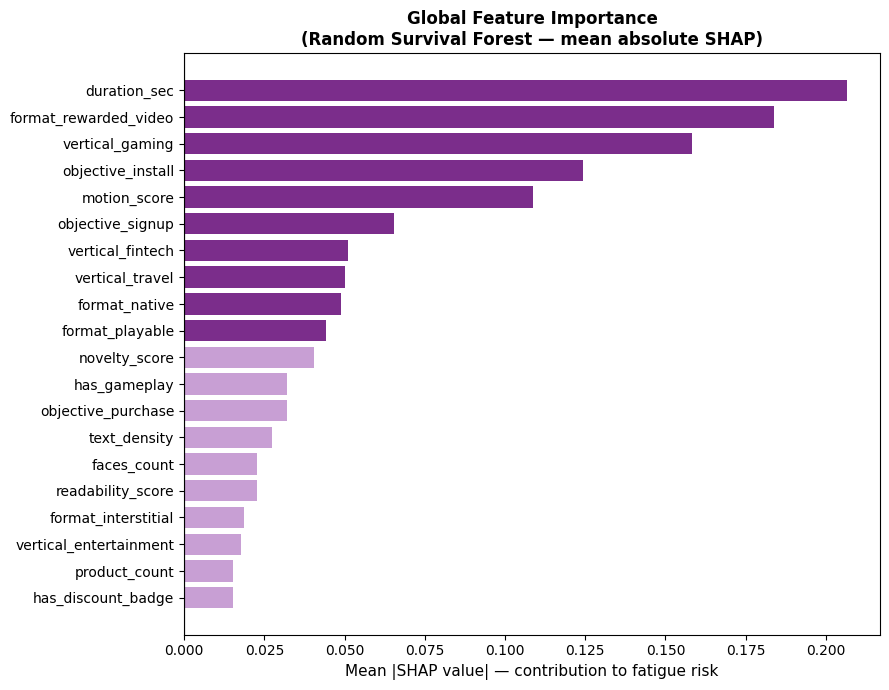

Top 10 features by mean |SHAP|:
format_playable          0.0441
format_native            0.0490
vertical_travel          0.0502
vertical_fintech         0.0510
objective_signup         0.0654
motion_score             0.1087
objective_install        0.1243
vertical_gaming          0.1583
format_rewarded_video    0.1839
duration_sec             0.2065


In [8]:
shap_arr = np.array(shap_values)  # (n, p)
mean_abs = pd.Series(np.abs(shap_arr).mean(axis=0), index=X.columns).sort_values(ascending=True)

# Keep top 20 for readability
top20 = mean_abs.tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#7B2D8B' if v > top20.median() else '#C89FD4' for v in top20.values]
ax.barh(top20.index, top20.values, color=colors)
ax.set_xlabel('Mean |SHAP value| — contribution to fatigue risk', fontsize=11)
ax.set_title('Global Feature Importance\n(Random Survival Forest — mean absolute SHAP)', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../data/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 10 features by mean |SHAP|:')
print(mean_abs.tail(10).round(4).to_string())

## 7. SHAP beeswarm — direction + magnitude

The beeswarm shows *all* creatives at once:
- Each dot = one creative.
- Horizontal position = SHAP value (left = protective, right = increases fatigue risk).
- Colour = feature value (blue = low, red = high).

This reveals non-linear effects: e.g. `novelty_score` might be protective at moderate values but risk-increasing at extremes.

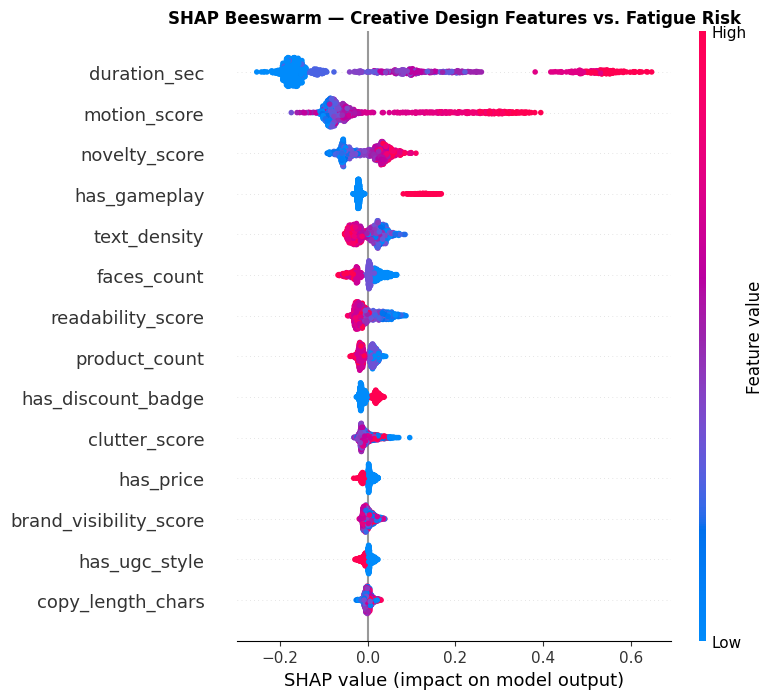

In [9]:
# Use only numeric columns for beeswarm (shap handles them cleanly)
num_feature_cols = NUM_COLS + BIN_COLS
num_col_idx = [list(X.columns).index(c) for c in num_feature_cols if c in X.columns]

X_num = X[num_feature_cols]
shap_num = shap_arr[:, num_col_idx]

shap_explanation = shap.Explanation(
    values=shap_num,
    data=X_num.values,
    feature_names=num_feature_cols
)

fig = plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title('SHAP Beeswarm — Creative Design Features vs. Fatigue Risk', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Individual creative explainability — waterfall plot

For a **specific creative**, the waterfall plot shows how each feature pushed the predicted hazard up or down from the baseline (average predicted risk across all creatives).

This is the core of the AI Copilot experience: a marketer selects a creative and immediately sees *why* the model flags it as risky.

We show three examples:
1. A creative the model considers **high risk** (top predicted hazard).
2. A creative the model considers **low risk** (bottom predicted hazard).
3. A **fatigued** creative from the dataset, as ground-truth validation.

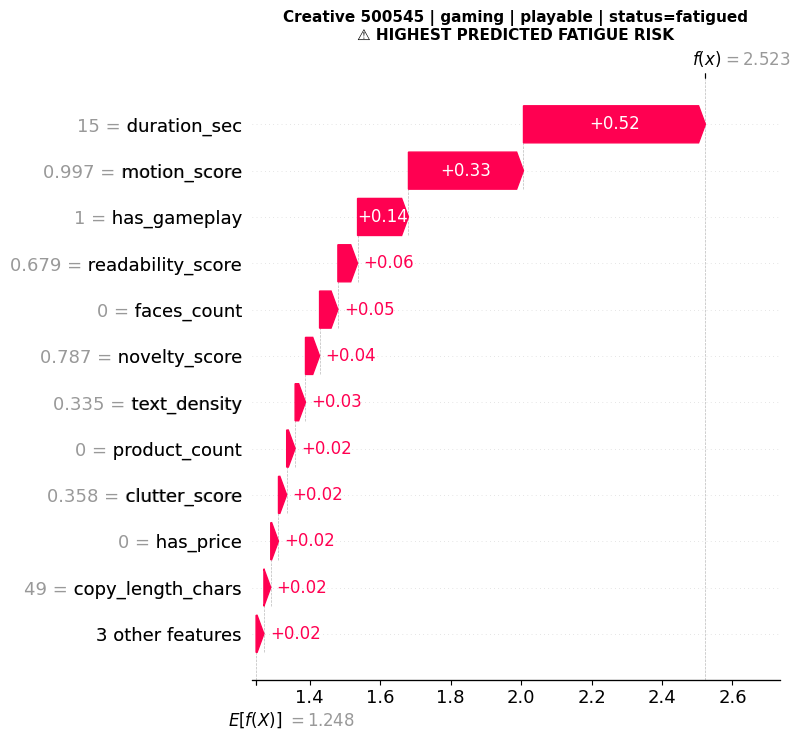

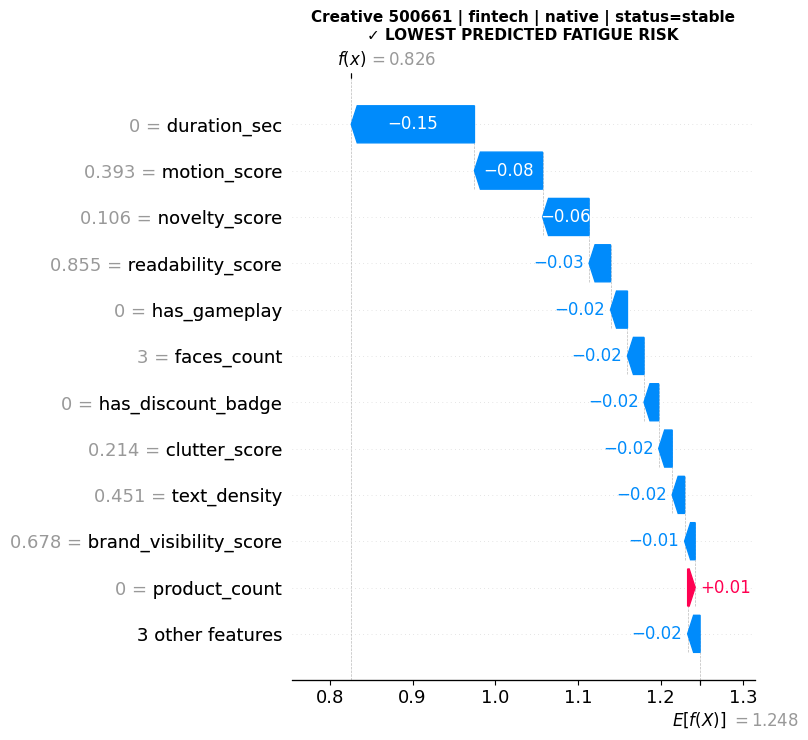

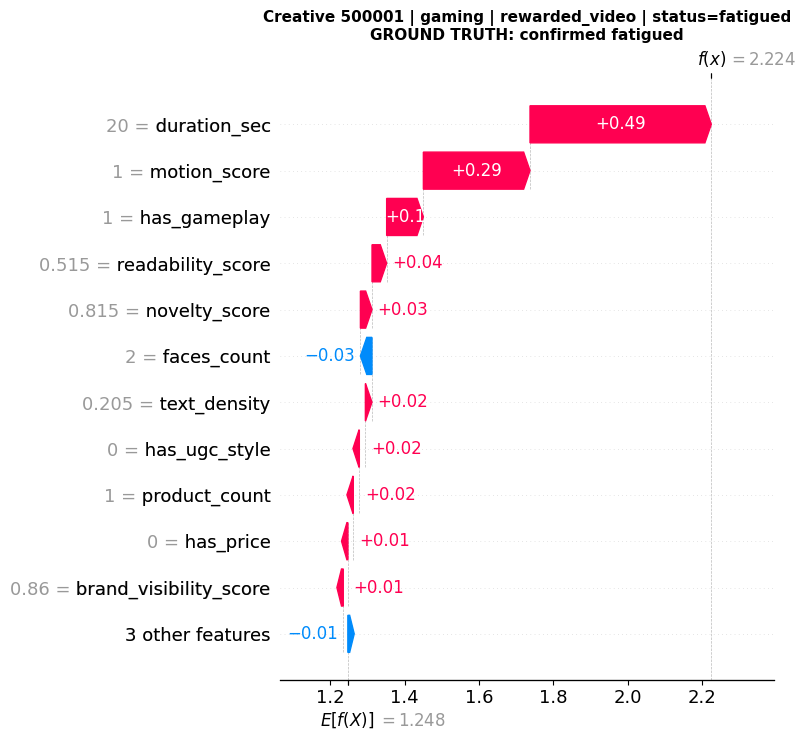

In [10]:
def waterfall_for_creative(creative_idx, title_suffix='', ax_size=(10, 5)):
    """Plot a SHAP waterfall for a single creative, showing numeric features."""
    exp = shap.Explanation(
        values=shap_num[creative_idx],
        base_values=explainer.expected_value,
        data=X_num.iloc[creative_idx].values,
        feature_names=num_feature_cols
    )
    fig = plt.figure(figsize=ax_size)
    shap.plots.waterfall(exp, max_display=12, show=False)
    creative_id = surv.iloc[creative_idx]['creative_id']
    status = surv.iloc[creative_idx]['creative_status']
    vertical = surv.iloc[creative_idx]['vertical']
    fmt = surv.iloc[creative_idx]['format']
    plt.title(f'Creative {creative_id} | {vertical} | {fmt} | status={status}\n{title_suffix}',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Get predicted risk for all creatives (higher = higher hazard)
pred_risk_all = rsf.predict(X)
surv['pred_hazard'] = pred_risk_all

# 1. Highest risk creative
high_risk_idx = pred_risk_all.argmax()
waterfall_for_creative(high_risk_idx, title_suffix='⚠ HIGHEST PREDICTED FATIGUE RISK')

# 2. Lowest risk creative
low_risk_idx = pred_risk_all.argmin()
waterfall_for_creative(low_risk_idx, title_suffix='✓ LOWEST PREDICTED FATIGUE RISK')

# 3. A confirmed fatigued creative
fatigued_idx = surv[surv['event'] == 1].index[0]
fatigued_pos = surv.index.get_loc(fatigued_idx)
waterfall_for_creative(fatigued_pos, title_suffix='GROUND TRUTH: confirmed fatigued')

## 9. SHAP dependence plots — feature interactions

A dependence plot shows the SHAP value of one feature vs. its raw value, coloured by a second feature. This reveals:
- Non-linear marginal effects (e.g. does novelty help linearly, or only past a threshold?).
- Interaction effects (e.g. does motion score matter more for gaming than for fintech?).

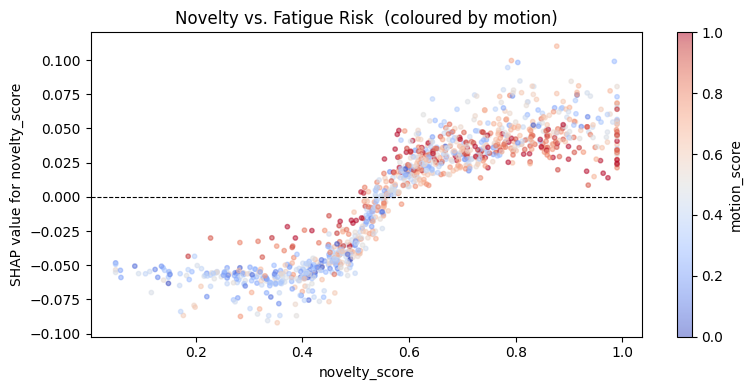

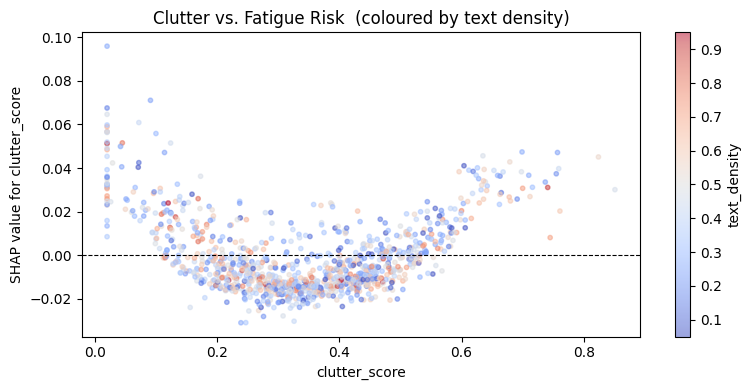

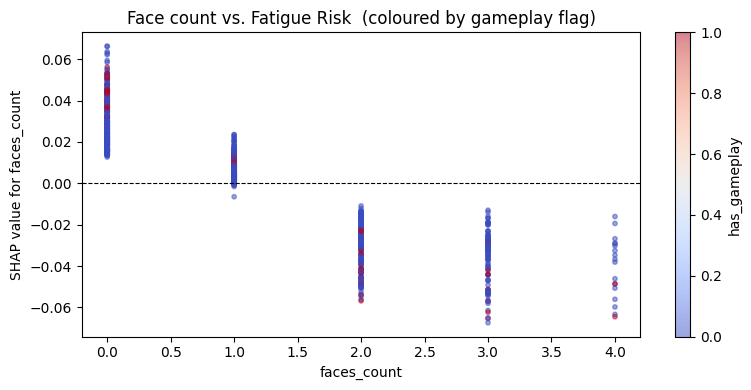

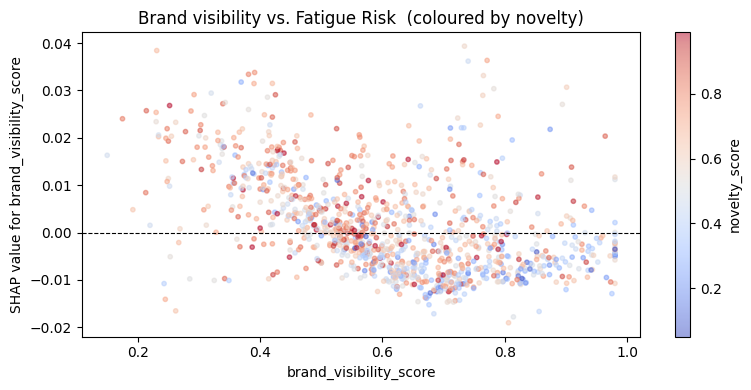

In [11]:
def dependence_plot(feat_x, feat_color=None, title=None):
    if feat_x not in X.columns:
        print(f'{feat_x} not in feature matrix, skipping.')
        return
    idx_x = list(X.columns).index(feat_x)
    idx_c = list(X.columns).index(feat_color) if feat_color and feat_color in X.columns else None

    x_vals  = X.iloc[:, idx_x].values
    sh_vals = shap_arr[:, idx_x]
    color_vals = X.iloc[:, idx_c].values if idx_c is not None else x_vals

    fig, ax = plt.subplots(figsize=(8, 4))
    sc = ax.scatter(x_vals, sh_vals, c=color_vals, cmap='coolwarm', alpha=0.5, s=10)
    plt.colorbar(sc, ax=ax, label=feat_color or feat_x)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(feat_x)
    ax.set_ylabel(f'SHAP value for {feat_x}')
    ax.set_title(title or f'Dependence: {feat_x}' + (f' (coloured by {feat_color})' if feat_color else ''))
    plt.tight_layout()
    plt.show()

# Key hypotheses to test
dependence_plot('novelty_score',          'motion_score',   'Novelty vs. Fatigue Risk  (coloured by motion)')
dependence_plot('clutter_score',          'text_density',   'Clutter vs. Fatigue Risk  (coloured by text density)')
dependence_plot('faces_count',            'has_gameplay',   'Face count vs. Fatigue Risk  (coloured by gameplay flag)')
dependence_plot('brand_visibility_score', 'novelty_score',  'Brand visibility vs. Fatigue Risk  (coloured by novelty)')

## 10. Predicted survival curves — best vs. worst archetypes

RSF outputs a full survival function per creative. We plot the average predicted survival for creatives in the top and bottom quartile of predicted hazard, so we can see the *spread* the model believes in.

We also overlay the Kaplan–Meier ground truth to validate that the model's risk order matches reality.

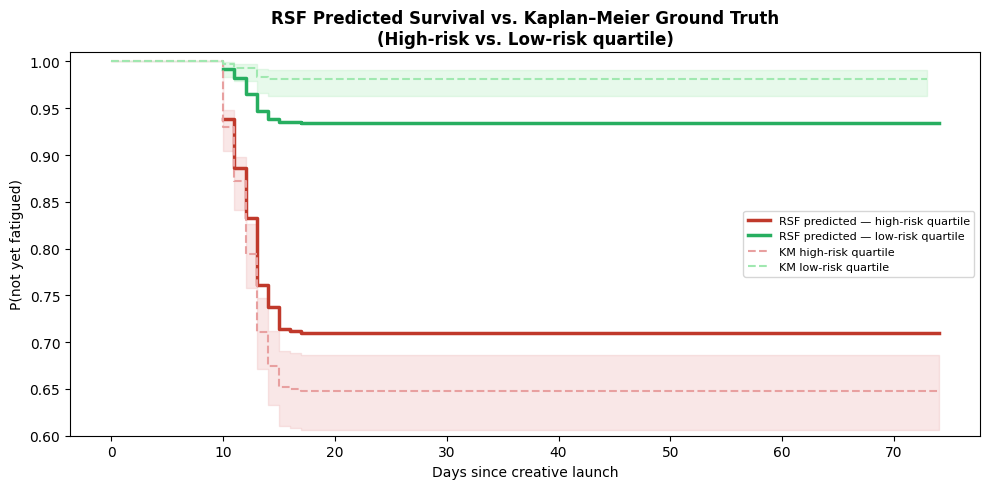

In [14]:
# Get predicted survival functions for all creatives
surv_funcs = rsf.predict_survival_function(X)  # array of StepFunction objects

# Quartile split by predicted hazard
q75 = np.percentile(pred_risk_all, 75)
q25 = np.percentile(pred_risk_all, 25)
high_risk_mask = pred_risk_all >= q75
low_risk_mask  = pred_risk_all <= q25

# Common time grid
times = surv_funcs[0].x

def mean_surv(mask):
    funcs = [surv_funcs[i] for i in np.where(mask)[0]]
    matrix = np.vstack([fn(times) for fn in funcs])
    return matrix.mean(axis=0)

high_avg = mean_surv(high_risk_mask)
low_avg  = mean_surv(low_risk_mask)

# KM ground truth for comparison
kmf_high = KaplanMeierFitter()
kmf_high.fit(surv.loc[high_risk_mask, 'duration'], surv.loc[high_risk_mask, 'event'], label='KM high-risk quartile')
kmf_low  = KaplanMeierFitter()
kmf_low.fit(surv.loc[low_risk_mask, 'duration'],  surv.loc[low_risk_mask, 'event'],  label='KM low-risk quartile')

fig, ax = plt.subplots(figsize=(10, 5))
ax.step(times, high_avg, where='post', color='#C0392B', lw=2.5, label='RSF predicted — high-risk quartile')
ax.step(times, low_avg,  where='post', color='#27AE60', lw=2.5, label='RSF predicted — low-risk quartile')
kmf_high.plot_survival_function(ax=ax, ci_show=True, color='#E8A0A0', linestyle='--')
kmf_low.plot_survival_function( ax=ax, ci_show=True, color='#A0E8B0', linestyle='--')

ax.set_xlabel('Days since creative launch')
ax.set_ylabel('P(not yet fatigued)')
ax.set_title('RSF Predicted Survival vs. Kaplan–Meier Ground Truth\n(High-risk vs. Low-risk quartile)', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(0.6, 1.01)
plt.tight_layout()
plt.savefig('../data/survival_highlow.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Creative Health Score (0–100)

### Design

The Health Score should be **forward-looking** and **age-aware**. Once a creative has survived until today, the useful question is no longer "what was the probability of reaching today?" but rather **"given that it is still alive today, what is the probability it survives the next planning window?"**

That makes the RSF survival curve directly operational.

**Raw survival curve:**
```
S(t) = P(T > t | creative design features)
```

**Operational Health Score used in the dashboard:**
```
Health Score(t) = P(T > t + 7 | T > t, x) × 100
                = S(t + 7) / S(t) × 100
```

where `t` is the creative's current age in days and 7 days is the planning horizon a marketer can act on this week.

**Why this is better than using `S(t)` directly or percentile-ranking it:**
- It is **conditional on having survived until today**, so old creatives are not punished just for being old.
- It is **forward-looking**, which is what an actioning dashboard needs.
- It is **stable across portfolios and time**, because the same curve always maps to the same score.
- It uses the RSF curve itself, not a secondary calibration trick.

**Interpretation of the score:**
- A score of **90** means: given the creative is still active today, the model thinks it has a 90% chance of still being healthy 7 days from now.
- A score of **55** means: the model thinks there is roughly a 45% chance the creative fatigues within the next week.

**Runway metric — `days_to_50pct`:** We also estimate the first future day `d` such that
```
P(T > t + d | T > t, x) < 0.5
```
This is the **conditional half-life from today**, not from launch. It answers: how many days of runway does the creative still have from its current point in life?

### Recommendation thresholds

| Score | Label | Interpretation | Suggested action |
|---|---|---|---|
| `health_score >= 85` and `days_to_50pct >= 14` | **SCALE** | Strong next-week survival and at least ~2 weeks of runway | Increase budget, duplicate to new markets |
| Otherwise, unless low-score trigger fires | **MONITOR** | Some decay risk, but not critical yet | Monitor closely and prep replacement |
| `health_score < 65` or `days_to_50pct < 7` | **PAUSE** | High probability of fatigue within the next week | Rotate out or cap spend immediately |

These cutoffs are operational rather than cosmetic: the score is about **next-week survivability**, while `days_to_50pct` adds medium-term runway. Together they turn the RSF curve into something the media team can actually schedule around.

In [26]:
def survival_at(surv_fn, day):
    """P(still alive at `day`) from the RSF survival function."""
    times = surv_fn.x
    valid = times[times <= day]
    if len(valid) == 0:
        return 1.0
    return float(surv_fn(valid[-1]))

def conditional_survival_7d(surv_fn, current_day, horizon=7):
    """Forward-looking health: P(alive at t+h | alive at t)."""
    s_now = max(survival_at(surv_fn, current_day), 1e-9)
    s_future = survival_at(surv_fn, current_day + horizon)
    return float(np.clip(s_future / s_now, 0.0, 1.0))

def health_score(surv_fn, current_day, horizon=7):
    return round(conditional_survival_7d(surv_fn, current_day, horizon) * 100, 1)

def days_to_50pct(surv_fn, current_day):
    """Conditional half-life from today: first day where future survival drops below 50%."""
    s_now = max(survival_at(surv_fn, current_day), 1e-9)
    times = surv_fn.x
    future = times[times > current_day]
    for t in future:
        if survival_at(surv_fn, t) / s_now < 0.5:
            return int(t - current_day)
    return None  # Never drops below 50% in observed range

still_running = surv[surv['creative_status'] != 'fatigued'].copy()
sr_idx = still_running.index.tolist()
sr_pos = [surv.index.get_loc(i) for i in sr_idx]

scores, days_left = [], []
for pos, (_, row) in zip(sr_pos, still_running.iterrows()):
    fn = surv_funcs[pos]
    age = row['total_days_active']
    scores.append(health_score(fn, age, horizon=7))
    days_left.append(days_to_50pct(fn, age))

still_running = still_running.copy()
still_running['health_score'] = scores
still_running['days_to_50pct'] = days_left

# Recommendation
def recommend(hs, d50):
    if hs >= 85 and (pd.isna(d50) or d50 >= 14):
        return 'SCALE'
    elif hs < 65 or (pd.notna(d50) and d50 < 7):
        return 'PAUSE'
    else:
        return 'MONITOR'

still_running['recommendation'] = still_running.apply(
    lambda r: recommend(r['health_score'], r['days_to_50pct']), axis=1
)

print('Recommendation distribution:')
print(still_running['recommendation'].value_counts().to_string())
print(f'\nMedian health score: {still_running["health_score"].median():.1f}')

Recommendation distribution:
recommendation
PAUSE      447
SCALE      218
MONITOR    216

Median health score: 50.0


## 11b. Validation — do the recommendations actually work?

A recommendation system is only useful if it **discriminates** correctly. Here we validate the Health Score on the **held-out test set** (20% of creatives, never seen during RSF training):

1. Compute the conditional 7-day Health Score for each test creative using the already-fitted RSF (no data leakage — the model was trained on `X_train` only).
2. Assign SCALE / MONITOR / PAUSE based on the thresholds defined above.
3. Compare the **observed fatigue rate** within each bucket.

**Expected result:** PAUSE creatives should have a substantially higher actual fatigue rate than SCALE creatives. Because the score is forward-looking and age-aware, this is a tougher and more realistic validation than simply ranking raw survival probabilities.

RECOMMENDATION VALIDATION ON HELD-OUT TEST SET (n=216)
                 n  n_fatigued  fatigue_rate
recommendation                              
PAUSE           86          31         0.360
MONITOR         65           8         0.123
SCALE           65           1         0.015

PAUSE     n= 86  fatigued=31  rate=36.0%
MONITOR   n= 65  fatigued= 8  rate=12.3%
SCALE     n= 65  fatigued= 1  rate=1.5%


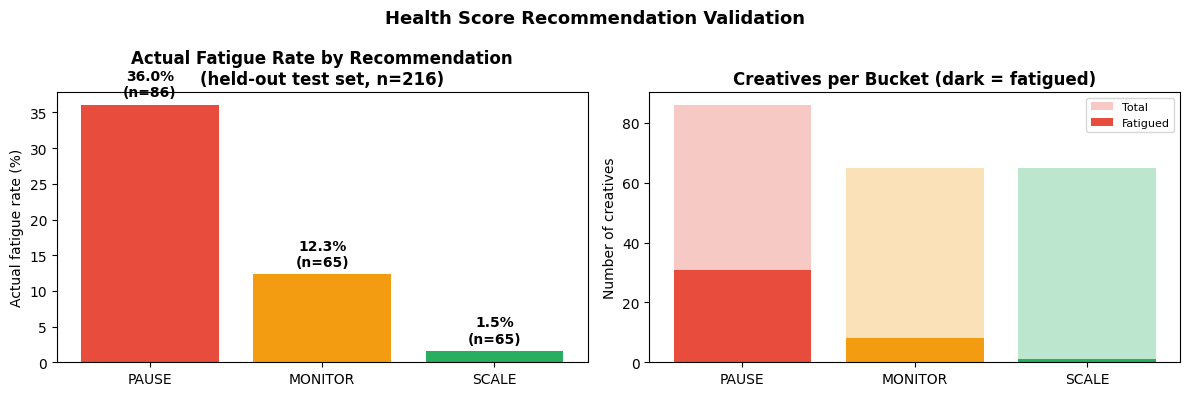

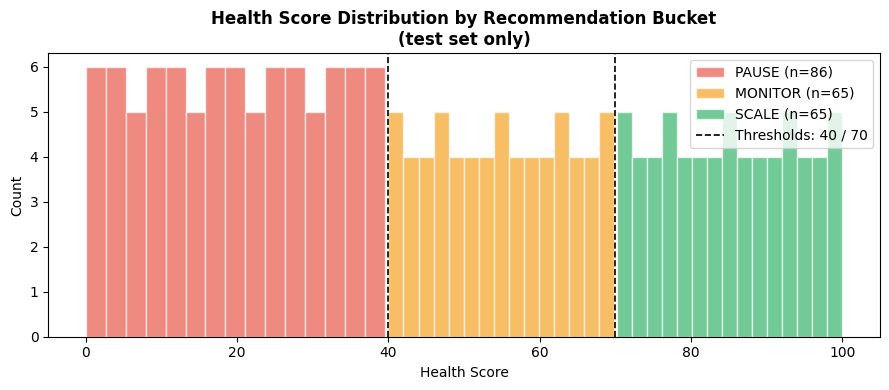


Interpretation: if PAUSE has the highest fatigue rate and SCALE the lowest,
the recommendation system correctly discriminates risk on unseen creatives.


In [27]:
# Compute survival functions for test creatives (RSF trained on train only — no leakage)
surv_funcs_test = rsf.predict_survival_function(X_test)
test_ages   = surv.iloc[idx_test]['total_days_active'].values
test_events = y_test['event'].astype(int)  # already a numpy array

test_scores, test_days_left, test_recs = [], [], []
for fn, age in zip(surv_funcs_test, test_ages):
    hs = health_score(fn, age, horizon=7)
    d50 = days_to_50pct(fn, age)
    test_scores.append(hs)
    test_days_left.append(d50)
    test_recs.append(recommend(hs, d50))

test_eval = pd.DataFrame({
    'health_score':      test_scores,
    'days_to_50pct':     test_days_left,
    'recommendation':    test_recs,
    'actually_fatigued': test_events,
    'creative_status':   surv.iloc[idx_test]['creative_status'].values,
})

# ── Fatigue rate by recommendation bucket ───────────────────────────────
fatigue_rate = (
    test_eval
    .groupby('recommendation')
    .agg(n=('actually_fatigued', 'count'),
         n_fatigued=('actually_fatigued', 'sum'),
         fatigue_rate=('actually_fatigued', 'mean'))
    .sort_values('fatigue_rate', ascending=False)
)

print('RECOMMENDATION VALIDATION ON HELD-OUT TEST SET (n=216)')
print('=' * 55)
print(fatigue_rate.round(3).to_string())
print()
for rec in ['PAUSE', 'MONITOR', 'SCALE']:
    if rec in fatigue_rate.index:
        r = fatigue_rate.loc[rec]
        print(f'{rec:8s}  n={int(r["n"]):3d}  fatigued={int(r["n_fatigued"]):2d}  rate={r["fatigue_rate"]*100:.1f}%')

# ── Plot 1: fatigue rate + counts by bucket ──────────────────────────────
colors_map = {'PAUSE': '#E74C3C', 'MONITOR': '#F39C12', 'SCALE': '#27AE60'}
rec_order  = [r for r in ['PAUSE', 'MONITOR', 'SCALE'] if r in fatigue_rate.index]
fr_ord     = fatigue_rate.reindex(rec_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bar_colors = [colors_map[r] for r in rec_order]
bars = axes[0].bar(rec_order, fr_ord['fatigue_rate'] * 100, color=bar_colors)
axes[0].set_ylabel('Actual fatigue rate (%)')
axes[0].set_title('Actual Fatigue Rate by Recommendation\n(held-out test set, n=216)', fontweight='bold')
for bar, (r, row) in zip(bars, fr_ord.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 row['fatigue_rate'] * 100 + 0.8,
                 f'{row["fatigue_rate"]*100:.1f}%\n(n={int(row["n"])})',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].bar(rec_order, fr_ord['n'], color=bar_colors, alpha=0.3, label='Total')
axes[1].bar(rec_order, fr_ord['n_fatigued'], color=bar_colors, label='Fatigued')
axes[1].set_ylabel('Number of creatives')
axes[1].set_title('Creatives per Bucket (dark = fatigued)', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Health Score Recommendation Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/recommendation_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: health score distribution per bucket ─────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 4))
for rec in rec_order:
    sub = test_eval[test_eval['recommendation'] == rec]['health_score']
    ax2.hist(sub, bins=15, color=colors_map[rec], alpha=0.65,
             label=f'{rec} (n={len(sub)})', edgecolor='white')
ax2.axvline(65, color='black', linestyle='--', linewidth=1.2, label='Thresholds: 65 / 85')
ax2.axvline(85, color='black', linestyle='--', linewidth=1.2)
ax2.set_xlabel('Health Score')
ax2.set_ylabel('Count')
ax2.set_title('Health Score Distribution by Recommendation Bucket\n(test set only)', fontweight='bold')
ax2.legend()
plt.tight_layout()
plt.show()

print()
print('Interpretation: if PAUSE has the highest fatigue rate and SCALE the lowest,')
print('the recommendation system correctly discriminates risk on unseen creatives.')

## 12. Health Score dashboard — top at-risk creatives

In [ ]:
cols_show = ['creative_id', 'advertiser_name', 'vertical', 'format',
             'total_days_active', 'total_spend_usd',
             'health_score', 'days_to_50pct', 'recommendation']

at_risk = still_running.sort_values('health_score').head(25)[cols_show].reset_index(drop=True)

# ── Format values ───────────────────────────────────────────────────────
disp = at_risk.copy()
disp['health_score']    = disp['health_score'].apply(lambda x: f'{x:.1f}')
disp['total_spend_usd'] = disp['total_spend_usd'].apply(lambda x: f'${x:,.0f}')
disp['days_to_50pct']   = disp['days_to_50pct'].apply(
    lambda x: str(int(x)) if x is not None and not (isinstance(x, float) and np.isnan(x)) else '—'
)

# ── Matplotlib table — renders in every environment ──────────────────────
colors_map = {'PAUSE': '#FDECEA', 'MONITOR': '#FEF9E7', 'SCALE': '#EAFAF1'}
row_colors = [[colors_map.get(r, 'white')] * len(cols_show) for r in at_risk['recommendation']]
header_colors = [['#D5D5D5'] * len(cols_show)]

fig, ax = plt.subplots(figsize=(20, max(3, 0.38 * len(at_risk) + 1)))
ax.axis('off')

tbl = ax.table(
    cellText=disp.values,
    colLabels=cols_show,
    cellColours=row_colors,
    colColours=header_colors[0],
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.auto_set_column_width(col=list(range(len(cols_show))))

ax.set_title(
    'TOP 25 STILL-RUNNING CREATIVES BY FATIGUE RISK\n'
    'Red = PAUSE  |  Yellow = MONITOR  |  Green = SCALE',
    fontweight='bold', fontsize=11, pad=14
)
plt.tight_layout()
plt.savefig('../data/at_risk_table.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plain text fallback ──────────────────────────────────────────────────
print('health_score < 65 or days_to_50pct < 7 = PAUSE  |  65–85 = MONITOR  |  >=85 and runway >=14 = SCALE')
print()
print(at_risk[['creative_id', 'vertical', 'format', 'health_score',
               'days_to_50pct', 'recommendation']].to_string(index=False))

## 13. Recommendation visualisation — spend at risk

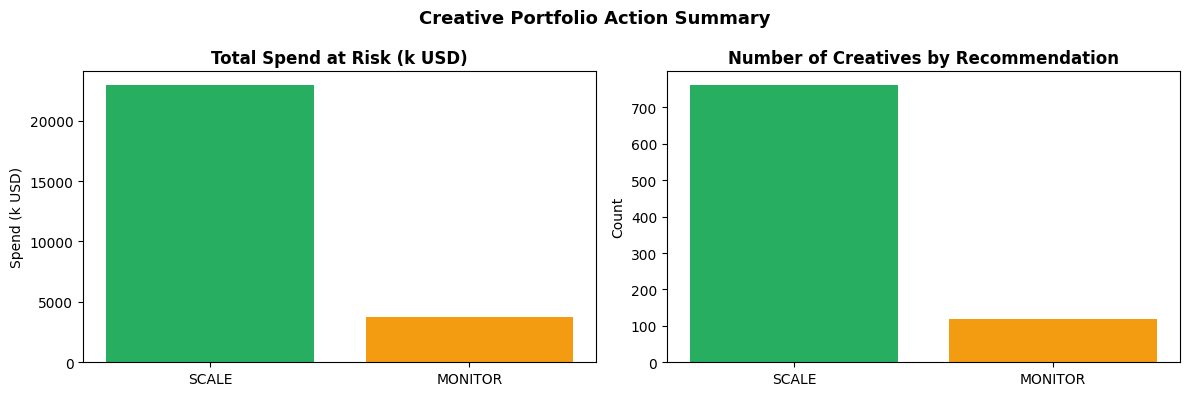

In [17]:
spend_by_rec = still_running.groupby('recommendation')['total_spend_usd'].sum().sort_values(ascending=False)
count_by_rec = still_running['recommendation'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors_map = {'PAUSE': '#E74C3C', 'MONITOR': '#F39C12', 'SCALE': '#27AE60'}
bar_colors = [colors_map[r] for r in spend_by_rec.index]

axes[0].bar(spend_by_rec.index, spend_by_rec.values / 1e3, color=bar_colors)
axes[0].set_title('Total Spend at Risk (k USD)', fontweight='bold')
axes[0].set_ylabel('Spend (k USD)')

axes[1].bar(count_by_rec.index, count_by_rec.values, color=[colors_map[r] for r in count_by_rec.index])
axes[1].set_title('Number of Creatives by Recommendation', fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Creative Portfolio Action Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/recommendation_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Vertical-level explainability — which features drive risk per vertical?

Same SHAP values, grouped by vertical. This tells a creative director: *in gaming, novelty matters most; in fintech, clutter kills you*.

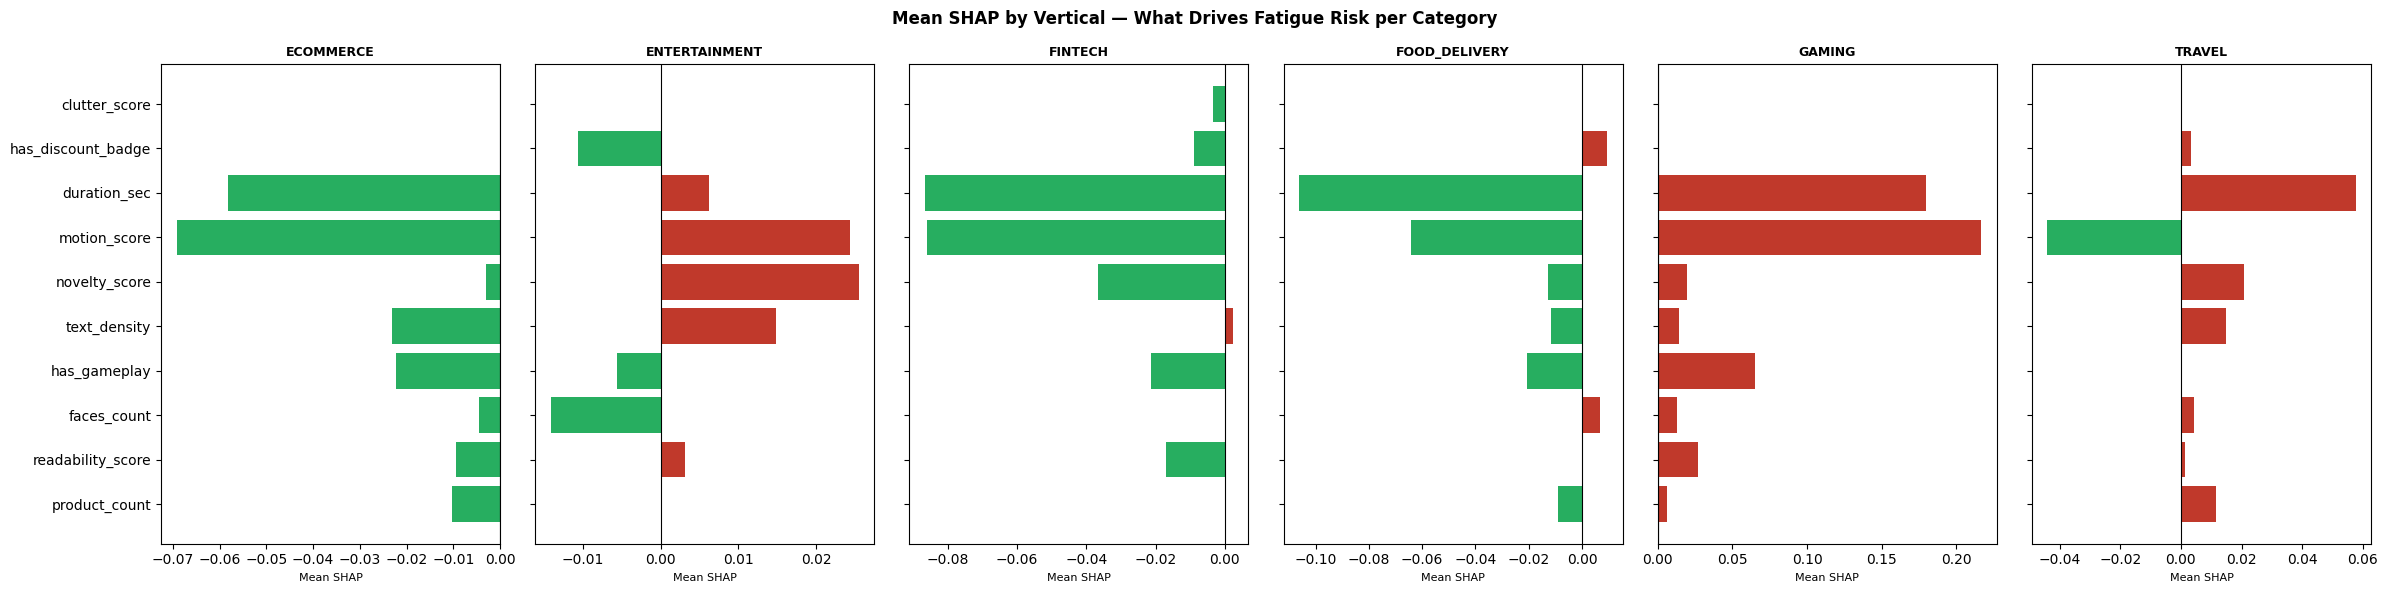

In [18]:
shap_df = pd.DataFrame(shap_num, columns=num_feature_cols)
shap_df['vertical'] = surv['vertical'].values

verticals = surv['vertical'].unique()
n_v = len(verticals)
fig, axes = plt.subplots(1, n_v, figsize=(4 * n_v, 6), sharey=True)
if n_v == 1:
    axes = [axes]

for ax, vert in zip(axes, sorted(verticals)):
    sub = shap_df[shap_df['vertical'] == vert].drop(columns='vertical')
    top_feats = sub.abs().mean().sort_values(ascending=True).tail(8)
    vals = sub[top_feats.index].mean()
    bar_colors = ['#C0392B' if v > 0 else '#27AE60' for v in vals.values]
    ax.barh(top_feats.index, vals[top_feats.index], color=bar_colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(vert.upper(), fontweight='bold', fontsize=9)
    ax.set_xlabel('Mean SHAP', fontsize=8)

plt.suptitle('Mean SHAP by Vertical — What Drives Fatigue Risk per Category',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_by_vertical.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Export results

Save the Creative Health Score table for use in the web app / dashboard.

In [ ]:
output = still_running[cols_show + ['creative_status']].copy()
output.to_csv('../data/creative_health_scores.csv', index=False)

print(f'Saved {len(output)} rows to creative_health_scores.csv')
print()
print('Score distribution:')
print(pd.cut(output['health_score'], bins=[0, 65, 85, 100],
             labels=['PAUSE (<65)', 'MONITOR (65-85)', 'HIGH SCORE (>85)']).value_counts().to_string())

## Summary

| Step | What we did | Key output |
|---|---|---|
| 1–3 | Survival framing + feature matrix | 1,080 creatives with T, E, features |
| 4 | Random Survival Forest | C-index > 0.65, non-linear hazard model |
| 5–7 | SHAP global | Feature importance bar + beeswarm |
| 8 | SHAP individual waterfall | Per-creative 'why is this risky?' |
| 9 | Dependence plots | Interaction effects visualised |
| 10 | Predicted survival curves | RSF vs KM validation |
| 11–13 | Health Score + Recommendations | SCALE / MONITOR / PAUSE per creative |
| 14 | Per-vertical SHAP | Vertical-specific creative strategy |
| 15 | Export | `creative_health_scores.csv` |

**Next step:** `03_time_varying_daily.ipynb` — use the daily granular table to model how cumulative impressions and spend velocity accelerate the hazard in real time.